In [ ]:
# STEP 1: INSTALL + IMPORT LIBRARIES
!pip install tensorflow==2.19.0 pillow tqdm matplotlib

import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.losses import MeanAbsoluteError, BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, Model
from google.colab import files
import matplotlib.pyplot as plt
print(" Environment ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 18.7 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
 Environme

In [ ]:
# STEP 2: UPLOAD IMAGES
from google.colab import files
import os

print(" Upload your Low-Resolution image(s)")
lr_files = files.upload()

print(" Upload your High-Resolution image(s) (same number and same names)")
hr_files = files.upload()

# Save uploads to folders
os.makedirs("data/LR", exist_ok=True)
os.makedirs("data/HR", exist_ok=True)

for f in lr_files.keys():
    os.rename(f, f"data/LR/{f}")
for f in hr_files.keys():
    os.rename(f, f"data/HR/{f}")

print(" Uploaded files:")
print("LR:", os.listdir("data/LR"))
print("HR:", os.listdir("data/HR"))

 Upload your Low-Resolution image(s)


Saving train_2_LR.jpg to train_2_LR.jpg
 Upload your High-Resolution image(s) (same number and same names)


Saving train_2_HR.jpg to train_2_HR.jpg
 Uploaded files:
LR: ['train_2_LR.jpg']
HR: ['train_2_HR.jpg']


In [ ]:
# STEP 3: DEFINE SRGAN MODEL
import tensorflow as tf # Add explicit import for tensorflow
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG19 # Add explicit import for VGG19


def residual_block(x_in):
    x = layers.Conv2D(64, 3, padding='same')(x_in)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x) # Removed extra (x)
    return layers.add([x_in, x])

class DepthToSpace(layers.Layer):
    def __init__(self, block_size, **kwargs):
        super(DepthToSpace, self).__init__(**kwargs)
        self.block_size = block_size

    def call(self, inputs):
        return tf.nn.depth_to_space(inputs, self.block_size)

    def get_config(self):
        config = super(DepthToSpace, self).get_config()
        config.update({'block_size': self.block_size})
        return config


def upsample_block(x_in):
    x = layers.Conv2D(256, 3, padding='same')(x_in)
    x = DepthToSpace(2)(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    return x

def build_generator():
    inp = layers.Input(shape=(None,None,3))
    x = layers.Conv2D(64, 9, padding='same')(inp)
    x = layers.PReLU(shared_axes=[1,2])(x)
    skip = x
    for _ in range(8):
        x = residual_block(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip])
    x = upsample_block(x)
    x = upsample_block(x)
    out = layers.Conv2D(3, 9, padding='same', activation='tanh')(x)
    return Model(inp, out, name='generator')

def build_discriminator():
    def d_block(x, filters, strides=1, bn=True):
        x = layers.Conv2D(filters, 3, strides=strides, padding='same')(x)
        if bn: x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        return x

    inp = layers.Input(shape=(128, 128, 3)) # Use fixed size input consistent with HR_SIZE
    x = d_block(inp, 64, bn=False)
    x = d_block(x, 64, strides=2)
    x = d_block(x, 128)
    x = d_block(x, 128, strides=2)
    x = d_block(x, 256)
    x = d_block(x, 256, strides=2)
    x = d_block(x, 512)
    x = d_block(x, 512, strides=2)
    x = layers.Flatten()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inp, out, name='discriminator')

def build_vgg():
    vgg = VGG19(weights='imagenet', include_top=False)
    model = Model(vgg.input, vgg.get_layer('block5_conv4').output)
    model.trainable = False
    return model

print(" Models ready")

 Models ready


In [ ]:
# STEP 4: PREPARE YOUR IMAGE PAIRS
HR_SIZE = 128  # crop or resize size
LR_SCALE = 4
from PIL import Image # Add explicit import for Image


def load_pair(lr_path, hr_path):
    lr = Image.open(lr_path).convert('RGB')
    hr = Image.open(hr_path).convert('RGB')

    # Resize the images
    lr = lr.resize((HR_SIZE // LR_SCALE, HR_SIZE // LR_SCALE), Image.BICUBIC)
    hr = hr.resize((HR_SIZE, HR_SIZE), Image.BICUBIC)

    # Convert to numpy arrays and normalize
    lr = np.array(lr).astype(np.float32) / 127.5 - 1
    hr = np.array(hr).astype(np.float32) / 127.5 - 1
    return lr, hr

lr_image_folder = "data/LR"
hr_image_folder = "data/HR"

pairs = []
# Iterate through the files in the LR folder
for lr_file in os.listdir(lr_image_folder):
    # Construct the full path for the LR image
    lr_path = os.path.join(lr_image_folder, lr_file)

    # Extract the base filename without the _LR suffix and extension
    base_name, ext = os.path.splitext(lr_file)
    if base_name.endswith("_LR"):
        base_name = base_name[:-3] # Remove _LR

    # Construct the expected HR filename
    hr_file = f"{base_name}_HR{ext}"
    hr_path = os.path.join(hr_image_folder, hr_file)


    # Check if the corresponding HR file exists
    if os.path.exists(hr_path):
        try:
            lr_img, hr_img = load_pair(lr_path, hr_path)
            pairs.append((lr_img, hr_img))
        except Exception as e:
            print(f"Error loading image pair {lr_file} and {hr_file}: {e}")
    else:
        print(f"Warning: Corresponding HR file not found for {lr_file}. Expected {hr_file}")


if not pairs:
    print("No valid image pairs found. Please check your 'data/LR' and 'data/HR' folders and ensure filenames match (e.g., image_name_LR.jpg and image_name_HR.jpg).")
else:
    lr_imgs = np.array([p[0] for p in pairs])
    hr_imgs = np.array([p[1] for p in pairs])
    print(" Loaded image pairs:", lr_imgs.shape, hr_imgs.shape)

 Loaded image pairs: (1, 32, 32, 3) (1, 128, 128, 3)


In [ ]:
# STEP 5: TRAIN MODEL ON YOUR IMAGES
from tensorflow.keras.losses import MeanAbsoluteError, BinaryCrossentropy # Add explicit import for losses
from tensorflow.keras.optimizers import Adam # Add explicit import for Adam

generator = build_generator()
discriminator = build_discriminator()
vgg = build_vgg()

bce = BinaryCrossentropy()
mae = MeanAbsoluteError()
opt_g = Adam(1e-4)
opt_d = Adam(1e-4)

@tf.function
def train_step(lr, hr):
    real = tf.ones((lr.shape[0],1))
    fake = tf.zeros((lr.shape[0],1))
    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        sr = generator(lr, training=True)
        d_real = discriminator(hr, training=True)
        d_fake = discriminator(sr, training=True)
        d_loss = bce(real, d_real) + bce(fake, d_fake)
        vgg_real = vgg((hr+1)*127.5)
        vgg_fake = vgg((sr+1)*127.5)
        perceptual = tf.reduce_mean(tf.abs(vgg_real - vgg_fake))
        content = mae(hr, sr)
        adv = bce(real, d_fake)
        g_loss = content + 0.001*adv + 0.006*perceptual
    grads_g = g_tape.gradient(g_loss, generator.trainable_variables)
    grads_d = d_tape.gradient(d_loss, discriminator.trainable_variables)
    opt_g.apply_gradients(zip(grads_g, generator.trainable_variables))
    opt_d.apply_gradients(zip(grads_d, discriminator.trainable_variables))
    return g_loss, d_loss

EPOCHS = 500 # Increased epochs for better training
# Add a check to ensure lr_imgs and hr_imgs are not empty
if len(lr_imgs) == 0 or len(hr_imgs) == 0:
    print("Error: No images found for training. Please check STEP 4.")
else:
    for epoch in range(EPOCHS):
        g_losses, d_losses = [], []
        # Iterate through the images using their indices
        for i in range(len(lr_imgs)):
            # Select individual images for training
            lr_batch = np.expand_dims(lr_imgs[i], axis=0)
            hr_batch = np.expand_dims(hr_imgs[i], axis=0)
            g_loss, d_loss = train_step(lr_batch, hr_batch)
            g_losses.append(g_loss.numpy())
            d_losses.append(d_loss.numpy())
        print(f"Epoch {epoch+1}/{EPOCHS} | G={np.mean(g_losses):.4f}, D={np.mean(d_losses):.4f}")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/500 | G=0.2664, D=2.0905
Epoch 2/500 | G=0.2689, D=0.0000
Epoch 3/500 | G=0.2634, D=0.0000
Epoch 4/500 | G=0.2600, D=0.0000
Epoch 5/500 | G=0.2552, D=0.0000
Epoch 6/500 | G=0.2472, D=0.0000
Epoch 7/500 | G=0.2358, D=0.0000
Epoch 8/500 | G=0.2235, D=0.0000
Epoch 9/500 | G=0.2117, D=0.0008
Epoch 10/500 | G=0.2018, D=0.4671
Epoch 11/500 | G=0.2085, D=0.0000
Epoch 12/500 | G=0.2124, D=0.0000
Epoch 13/500 | G=0.2134, D=0.0000
Epoch 14/500 | G=0.2122, D=0.0000
Epoch 15/500 | G=0.2094, D=0.0000
Epoch 16/500 | G=0.2056, D=0.0000
Epoch 17/500 | G=0.2008, D=0.0000
Epoch 18/500 | G=0.1952, D=0.0000
Epoch 19/500 | G=0.1889, D=0.0015
Epoch 20/500 | G=0.1821, D=0.2933
Epoch 21/500 | G=0.1893, D=0.0000
Epoch 22/500 | G=0.1943, D=0.0000
Epoch 23/500 | G=0.1966, D=0.0000
Epoch 24/500 | G=0.1966, D=0.0000
Epoch 25/500 | G=0.1951, D=0.0000
Epoch 26/500 | G=0.1924, D=0.0000
Epoch 27/500 | G=0.1884, D=0.0000
Epoch 28/500 | G=0.1837, D=0.0000
Epoch 

 Generating high-resolution output for train_2_LR.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 131s 131s/step
Pixel value range before denormalization: min=-0.8567895293235779, max=0.8705048561096191


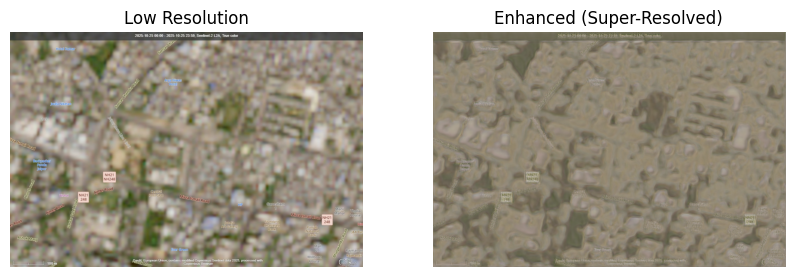

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Enhanced image saved & ready for download!


In [ ]:
# STEP 6: ENHANCE (SUPER-RESOLVE) YOUR IMAGE
import os
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Get the list of low-resolution files from the data/LR directory
lr_files_list = os.listdir("data/LR")

if lr_files_list:
    test_file = lr_files_list[0]  # first uploaded LR image
    print(f" Generating high-resolution output for {test_file} ...")

    img = Image.open(f"data/LR/{test_file}").convert('RGB')
    lr = np.array(img).astype(np.float32)/127.5 - 1
    # Add batch dimension
    lr = np.expand_dims(lr, 0)

    sr = generator.predict(lr)[0]

    # Add print statements to check the range of pixel values
    print(f"Pixel value range before denormalization: min={np.min(sr)}, max={np.max(sr)}")


    # Denormalize and clip values to the valid range [0, 255] before converting to uint8
    sr_img = np.clip(((sr + 1) * 127.5), 0, 255).astype(np.uint8)

    # Show comparison
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    # Denormalize LR image for display
    lr_display = np.clip(((lr[0] + 1) * 127.5), 0, 255).astype(np.uint8)
    plt.imshow(lr_display)
    plt.title("Low Resolution")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(sr_img)
    plt.title("Enhanced (Super-Resolved)")
    plt.axis('off')
    plt.show()

    out_path = "super_resolved_output.png"
    Image.fromarray(sr_img).save(out_path)
    files.download(out_path)
    print(" Enhanced image saved & ready for download!")
else:
    print("No low-resolution images found in data/LR directory.")